# Customer Targeting Optimization using Uplift Modeling

This project uses uplift modeling (causal machine learning) to identify customers who should be targeted with marketing emails to maximize conversion and reduce cost.

## Problem Statement

Companies often send marketing emails to all customers, but not everyone responds.  
This leads to wasted marketing cost and poor customer experience.

The goal of this project is to identify customers who are most likely to respond **because of the email**, not just those who are likely to purchase anyway.

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [25]:
# ==========================================
# Customer Uplift Modeling Project
# ==========================================

In [2]:
!pip install scikit-uplift
from sklift.datasets import fetch_hillstrom

## Dataset Overview

We use the Hillstrom dataset which contains customer behavior and marketing campaign data.

- Target → Whether customer made a purchase
- Treatment → Whether customer received email
- Features → Customer history, recency, product interest, etc.

In [3]:
# ==========================================
# 1. Data Loading
# ==========================================


import pandas as pd
from sklift.datasets import fetch_hillstrom
hillstrom_data = fetch_hillstrom()
df = pd.DataFrame(hillstrom_data['data'], columns=hillstrom_data['feature_names'])
df['target'] = hillstrom_data['target']
df['treatment'] = hillstrom_data['treatment']
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,0,Womens E-Mail


In [4]:
df.shape

(64000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   target           64000 non-null  int64  
 9   treatment        64000 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 4.9+ MB


In [7]:
df.describe()

,recency,history,mens,womens,newbie,target
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000


## Exploratory Data Analysis

We analyze:
- Distribution of target (purchase behavior)
- Distribution of treatment (email vs no email)
- Conversion rate comparison between treatment and control groups

This helps us understand the impact of marketing.

Target Distribution:
 target
0    54606
1     9394
Name: count, dtype: int64

Treatment Distribution:
 treatment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


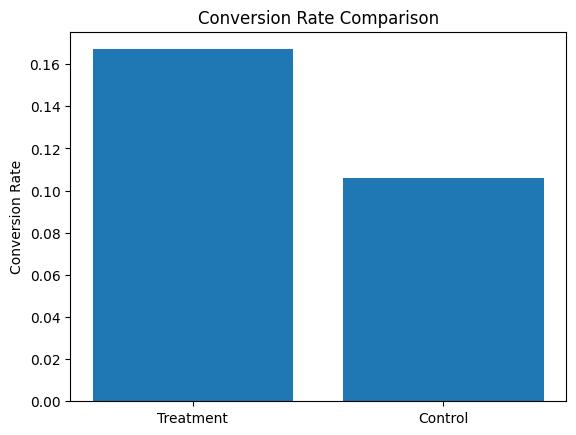

In [8]:
# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================

import matplotlib.pyplot as plt

print("Target Distribution:\n", df['target'].value_counts())
print("\nTreatment Distribution:\n", df['treatment'].value_counts())

# Conversion comparison
treatment_rate = df[df['treatment'] != 'No E-Mail']['target'].mean()
control_rate = df[df['treatment'] == 'No E-Mail']['target'].mean()

plt.bar(['Treatment', 'Control'], [treatment_rate, control_rate])
plt.title("Conversion Rate Comparison")
plt.ylabel("Conversion Rate")
plt.show()

## Data Preprocessing

- Converted treatment column into binary format
- Split data into treatment and control groups
- Removed unnecessary columns
- Applied one-hot encoding to categorical features

In [9]:
# ==========================================
# 3. Data Preprocessing
# ==========================================

df['treatment_binary'] = df['treatment'].apply(
    lambda x: 0 if x == 'No E-Mail' else 1
)

# Split groups
treatment_group = df[df['treatment_binary'] == 1]
control_group = df[df['treatment_binary'] == 0]

print("Treatment size:", len(treatment_group))
print("Control size:", len(control_group))

print("Treatment Conversion:", treatment_group['target'].mean())
print("Control Conversion:", control_group['target'].mean())

Treatment size: 42694
Control size: 21306
Treatment Conversion: 0.16704923408441466
Control Conversion: 0.10616727682343002


In [10]:
# ==========================================
# Feature Engineering
# ==========================================

# Separate target
y_treat = treatment_group['target']
y_control = control_group['target']

# Remove unnecessary columns
drop_cols = ['target', 'treatment']

X_treat = treatment_group.drop(columns=drop_cols)
X_control = control_group.drop(columns=drop_cols)

# Remove constant column
X_treat = X_treat.drop(columns=['treatment_binary'])
X_control = X_control.drop(columns=['treatment_binary'])

In [11]:
# Combine for consistent encoding
X_all = pd.concat([X_treat, X_control])

# One-hot encoding
X_all_encoded = pd.get_dummies(X_all, drop_first=True)

# Split back
X_treat = X_all_encoded.loc[X_treat.index]
X_control = X_all_encoded.loc[X_control.index]

In [12]:
# ==========================================
# 4. Uplift Modeling (T-Learner)
# ==========================================

"""
We train two models:
1. Treatment model → predicts purchase if email is sent
2. Control model → predicts purchase if email is NOT sent

Uplift = Difference between probabilities
"""

'\nWe train two models:\n1. Treatment model → predicts purchase if email is sent\n2. Control model → predicts purchase if email is NOT sent\n\nUplift = Difference between probabilities\n'

In [13]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_treat_train, X_treat_test, y_treat_train, y_treat_test = train_test_split(
    X_treat, y_treat, test_size=0.3, random_state=42
)

X_control_train, X_control_test, y_control_train, y_control_test = train_test_split(
    X_control, y_control, test_size=0.3, random_state=42
)

## Uplift Modeling Approach (T-Learner)

We use a two-model approach:

- Treatment Model → Predicts purchase probability if email is sent
- Control Model → Predicts purchase probability if email is NOT sent

Uplift Score = Difference between the two predictions

This helps identify customers influenced by marketing.

In [14]:
# ==========================================
# 5. Model Training
# ==========================================

from sklearn.ensemble import RandomForestClassifier

model_treat = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

model_control = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

model_treat.fit(X_treat_train, y_treat_train)
model_control.fit(X_control_train, y_control_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Model Evaluation

We evaluate the model using:

- Uplift score distribution
- Top 10% customer performance
- (Optional) Qini curve

This helps measure how well the model identifies high-impact customers.

In [18]:
# ==========================================
# 6. Evaluation
# ==========================================

df['uplift_score'] = uplift

df_sorted = df.sort_values(by='uplift_score', ascending=False)

# Top 10% performance
top_10 = df_sorted.head(int(0.1 * len(df)))

print("Top 10% Conversion Rate:", top_10['target'].mean())
print("Overall Conversion Rate:", df['target'].mean())

Top 10% Conversion Rate: 0.14625
Overall Conversion Rate: 0.14678125


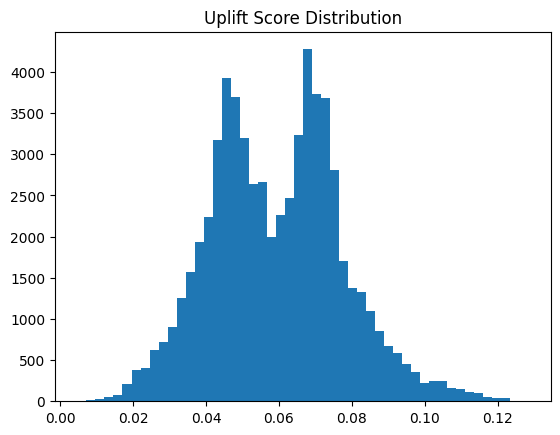

In [19]:
plt.hist(df['uplift_score'], bins=50)
plt.title("Uplift Score Distribution")
plt.show()

In [20]:
import numpy as np

def explain_user(row):
    reasons = []

    if row['history'] > np.percentile(df['history'], 75):
        reasons.append("high spending customer")

    if row['recency'] < np.percentile(df['recency'], 25):
        reasons.append("recently active")

    if row['uplift_score'] > 0.1:
        reasons.append("high response to marketing")

    return "Customer likely to respond because: " + ", ".join(reasons)

## Feature Importance

We analyze which features influence customer response using feature importance from the treatment model.

This helps understand key drivers of customer behavior.

In [35]:
# ==========================================
# Feature Importance (Treatment Model)
# ==========================================

import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_treat.columns,
    'importance': model_treat.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                           feature  importance
1                          history    0.241927
0                          recency    0.184939
4                           newbie    0.181370
3                           womens    0.103499
2                             mens    0.073178
13                   channel_Phone    0.052223
14                     channel_Web    0.038601
7   history_segment_4) $350 - $500    0.032937
5   history_segment_2) $100 - $200    0.017439
11              zip_code_Surburban    0.015699


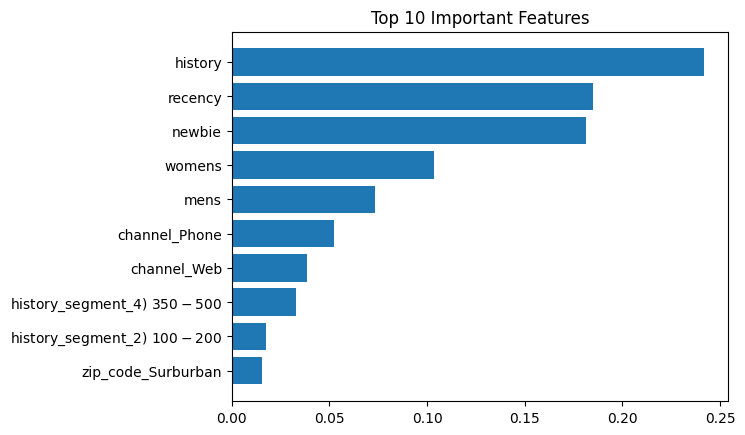

In [36]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [37]:
# ==========================================
# Predict & Calculate Uplift
# ==========================================

# Predict probabilities
pred_treat = model_treat.predict_proba(X_all_encoded)[:, 1]
pred_control = model_control.predict_proba(X_all_encoded)[:, 1]

# Uplift score
uplift = pred_treat - pred_control

## Business Insights

- Not all customers should be targeted with marketing emails
- Targeting high uplift customers improves conversion rate
- Some customers may have negative uplift → should NOT be targeted
- Personalized marketing is more effective than mass campaigns

In [21]:
# ==========================================
# 7. Business Insights
# ==========================================

"""
Key Takeaways:

1. Not all customers should receive marketing emails
2. Targeting top uplift users improves conversion rate
3. Some users may have negative uplift → avoid targeting them
4. Personalized marketing is more effective than mass campaigns
"""

'\nKey Takeaways:\n\n1. Not all customers should receive marketing emails\n2. Targeting top uplift users improves conversion rate\n3. Some users may have negative uplift → avoid targeting them\n4. Personalized marketing is more effective than mass campaigns\n'

In [32]:
# ==========================================
# Qini Curve
# ==========================================


from sklift.metrics import qini_auc_score

score = qini_auc_score(
    y_true=df['target'],
    uplift=uplift,
    treatment=df['treatment_binary']
)

print("Qini AUC Score:", score)

Qini AUC Score: -0.010893897565975088


In [33]:
# ==========================================
# Uplift Segmentation
# ==========================================

def segment_uplift(score):
    if score > 0.1:
        return "Persuadable"
    elif score < -0.05:
        return "Do Not Target"
    else:
        return "Neutral"

df['segment'] = df['uplift_score'].apply(segment_uplift)

print(df['segment'].value_counts())

segment
Neutral        62746
Persuadable     1254
Name: count, dtype: int64


In [34]:
# Top customers to target
top_customers = df_sorted.head(20)

print(top_customers[['uplift_score']])

       uplift_score
40243      0.128456
29507      0.127290
19916      0.127290
62502      0.125875
58939      0.125519
50822      0.125079
15622      0.124895
28076      0.123817
6806       0.123238
63848      0.123238
30361      0.123238
38882      0.122827
8781       0.122827
13293      0.122827
17683      0.122679
23864      0.122608
6703       0.122608
29051      0.122605
59867      0.122569
31093      0.122569
